# Text-only robustness (Qwen captions, **legacy stratified splits**)

**Row table for `train_test_split`:** **`data/processed/LLaVA_caption_dataset_final_full.csv`** (success rows), or legacy **`caption_dataset_final_full.csv`**. Same **70% / 15% / 15%** and seeds as **`TextOnly_LLaVA_StratifiedSplits_Robustness.ipynb`**.

**Qwen file (`qwen25vl_caption_full.csv`)** is used only for **caption text** (lookup by `image_path`), not for defining which rows enter the stratified split. The two CSVs are *not* interchangeable for splits unless every `image_path` (and row set) matches the LLaVA table exactly — in practice the LLaVA table defines parity with the LLaVA notebook.

**Override:** env **`FASHION_STRATIFIED_TABLE_CSV`** → path to a table with `image_path`, `style`, `status` (same role as the LLaVA file).

If the processed LLaVA file is missing, the notebook **errors** with both default paths; fix paths or set the env var (do not silently use the Qwen CSV for splits).

Use this notebook for **fair comparison** with LLaVA text-only and with **`AttentionFusion_FinetunedCLIP_Qwen_Robustness.ipynb`** when that notebook is in **`SPLIT_MODE = "stratified"`**.

For **fixed `data/splits/seed_*`** (aligned with CSV-finetuned CLIP / image-only), use **`AttentionFusion_FinetunedCLIP_Qwen_Robustness.ipynb`** with **`SPLIT_MODE = "csv"`**.

## Outputs
`experiments/textonly_qwen_stratified_splits_robustness/`

Set **`RUN_ALL_SEEDS = True`** for all seeds in `seeds_list.txt`, or **`False`** + **`SMOKE_SEED`** for one run.

After pulling or regenerating this notebook, use **Kernel → Restart** (then Run All). Otherwise Jupyter can still run an **old cached** first cell (e.g. the removed CAPTION_CSV split fallback).

## Notes
- **`seeds_list.txt`:** seeds are read only from lines matching `N. Seed <id>` (the 30 protocol entries). Header numbers like `Total seeds: 30` are ignored.
- Only the **classifier** is optimized; BERT stays effectively frozen (see model `train()` override in the code cell).

In [1]:
import os
import re
import json
import time
import warnings
from pathlib import Path
from urllib.parse import unquote

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

# --- project root ---
_walk = os.path.abspath(os.getcwd())
for _ in range(10):
    if os.path.isdir(os.path.join(_walk, "experiments")) and os.path.isdir(os.path.join(_walk, "data")):
        PROJECT_ROOT = _walk
        break
    _walk = os.path.dirname(_walk)
else:
    PROJECT_ROOT = os.path.abspath(os.getcwd())
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)

CAPTION_CSV = os.path.join(PROJECT_ROOT, "data", "captions", "qwen25vl_caption_full.csv")
if not os.path.isfile(CAPTION_CSV):
    raise FileNotFoundError(f"Missing Qwen caption CSV: {CAPTION_CSV}")

VAL_RATIO = 0.15
TEST_RATIO = 0.15
_llava_t = os.path.join(PROJECT_ROOT, "data", "processed", "LLaVA_caption_dataset_final_full.csv")
_legacy_t = os.path.join(PROJECT_ROOT, "data", "processed", "caption_dataset_final_full.csv")
if os.path.isfile(_llava_t):
    _default_table = _llava_t
elif os.path.isfile(_legacy_t):
    _default_table = _legacy_t
else:
    _default_table = _llava_t
LEGACY_TABLE_CSV = os.environ.get("FASHION_STRATIFIED_TABLE_CSV", _default_table).strip()
if LEGACY_TABLE_CSV and not os.path.isabs(LEGACY_TABLE_CSV):
    LEGACY_TABLE_CSV = os.path.normpath(os.path.join(PROJECT_ROOT, LEGACY_TABLE_CSV))

if not os.path.isfile(LEGACY_TABLE_CSV):
    raise FileNotFoundError(
        "Stratified split table not found.\n"
        "  Checked (defaults):\n    "
        + _llava_t
        + "\n    "
        + _legacy_t
        + "\n  Resolved LEGACY_TABLE_CSV (after env FASHION_STRATIFIED_TABLE_CSV):\n    "
        + repr(LEGACY_TABLE_CSV)
        + "\n  Add LLaVA_caption_dataset_final_full.csv under data/processed/, or set FASHION_STRATIFIED_TABLE_CSV "
        "to a CSV with the same columns as the LLaVA stratified notebook (image_path, style, status).\n"
        "  The Qwen caption file is only used for **text**; it does not replace the LLaVA table for row membership."
    )

print("Stratified row table:", LEGACY_TABLE_CSV)
DF_FULL = pd.read_csv(LEGACY_TABLE_CSV)
if "status" in DF_FULL.columns:
    DF_FULL = DF_FULL[DF_FULL["status"].astype(str).str.lower() == "success"].copy()
DF_FULL["style"] = DF_FULL["style"].astype(str).str.strip()
all_styles = sorted(DF_FULL["style"].dropna().unique())
style_to_idx = {s: i for i, s in enumerate(all_styles)}
num_classes = len(all_styles)
print("Legacy table rows:", len(DF_FULL), "| num_classes:", num_classes)

EXPERIMENT_ROOT = os.path.join(PROJECT_ROOT, "experiments", "textonly_qwen_stratified_splits_robustness")
METRICS_DIR = os.path.join(EXPERIMENT_ROOT, "metrics")
ARTIFACTS_DIR = os.path.join(EXPERIMENT_ROOT, "artifacts")
for d in [
    METRICS_DIR,
    os.path.join(METRICS_DIR, "experiments"),
    os.path.join(ARTIFACTS_DIR, "models"),
    os.path.join(ARTIFACTS_DIR, "learning_curves"),
    os.path.join(ARTIFACTS_DIR, "comparison_plots"),
]:
    os.makedirs(d, exist_ok=True)

RUN_ALL_SEEDS = True
SMOKE_SEED = 13
LEARNING_RATE = 5e-5
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 20
MODEL_INIT_SEED = 42
NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu")
print("Device:", device)
print("CAPTION_CSV:", CAPTION_CSV)
print("EXPERIMENT_ROOT:", EXPERIMENT_ROOT)

seeds_file = os.path.join(PROJECT_ROOT, "data", "processed", "seeds_list.txt")
SEEDS = []
if os.path.isfile(seeds_file):
    with open(seeds_file) as f:
        content = f.read()
    # Prefer "N. Seed <id>" lines (data/processed/seeds_list.txt); do not scrape every digit
    # (would pull 1, 30, 42, 500, line indices, etc. and inflate the count).
    listed = re.findall(r"(?m)^\s*\d+\.\s*Seed\s+(\d+)\s*$", content)
    for num_str in listed:
        v = int(num_str)
        if 1 <= v <= 500:
            SEEDS.append(v)
    if not SEEDS:
        for num_str in re.findall(r"\d+", content):
            try:
                v = int(num_str)
                if 1 <= v <= 500:
                    SEEDS.append(v)
            except ValueError:
                pass
        SEEDS = sorted(set(SEEDS))
        print(f"Warning: no 'N. Seed <id>' lines in {seeds_file}; fell back to digit scan -> {len(SEEDS)} values")
    else:
        SEEDS = sorted(set(SEEDS))
    print(f"Loaded {len(SEEDS)} seeds from {seeds_file}")
else:
    print("Warning: seeds_list.txt missing — SEEDS empty")

with open(os.path.join(METRICS_DIR, "seeds_list.txt"), "w") as f:
    f.write("Seeds from data/processed/seeds_list.txt (stratified protocol)\n")
    for s in SEEDS:
        f.write(f"{s}\n")


def resolve_split_image_path(row_image_path, base_dir):
    base = base_dir or "."
    p = str(row_image_path)
    if not os.path.isabs(p):
        rel = p.replace(chr(92), "/")
        dataset_top = os.path.join(base, "dataset")
        if rel.startswith("dataset/") and not os.path.isdir(dataset_top):
            p = os.path.join(base, "data", "raw dataset", rel[len("dataset/") :])
        else:
            p = os.path.join(base, p)
    if "%" in p:
        parts = p.replace(chr(92), "/").split("/")
        p = "/".join(unquote(part) if "%" in part else part for part in parts)
    return os.path.normpath(p)


def load_caption_dict(csv_path: str, base_dir: str):
    df = pd.read_csv(csv_path)
    if "status" in df.columns:
        df = df[df["status"].astype(str).str.lower() == "success"].copy()
    if "caption" not in df.columns or "image_path" not in df.columns:
        raise ValueError(f"Expected image_path and caption columns; got {list(df.columns)}")

    def register(d, raw_path, text):
        t = str(text).strip()
        if not t:
            return
        p = str(raw_path)
        d[p] = t
        d[os.path.normpath(p)] = t
        if base_dir and not os.path.isabs(p):
            d[os.path.normpath(os.path.join(base_dir, p))] = t
        res = resolve_split_image_path(p, base_dir or ".")
        d[res] = t

    out = {}
    for _, row in df.iterrows():
        register(out, row["image_path"], row["caption"])
    return out


BASE_DIR = PROJECT_ROOT
captions_dict = load_caption_dict(CAPTION_CSV, BASE_DIR)
print("Caption dict entries (with path aliases):", len(captions_dict))


/home/ding-zhang/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /home/ding-zhang/Dongmei/DATA255/Project
Stratified row table: /home/ding-zhang/Dongmei/DATA255/Project/data/processed/LLaVA_caption_dataset_final_full.csv
Legacy table rows: 13230 | num_classes: 14
Device: cuda
CAPTION_CSV: /home/ding-zhang/Dongmei/DATA255/Project/data/captions/qwen25vl_caption_full.csv
EXPERIMENT_ROOT: /home/ding-zhang/Dongmei/DATA255/Project/experiments/textonly_qwen_stratified_splits_robustness
Loaded 30 seeds from /home/ding-zhang/Dongmei/DATA255/Project/data/processed/seeds_list.txt
Caption dict entries (with path aliases): 39588


## Load BERT

In [2]:
print("Loading BERT …")
fashionbert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
fashionbert_model = AutoModel.from_pretrained("bert-base-uncased").to(device)
fashionbert_model.eval()
print("BERT ready.")


Loading BERT …


2026-05-21 17:53:36.498024: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-21 17:53:36.522816: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-21 17:53:37.155487: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


BERT ready.


## Dataset, model, train/val

In [3]:
class FashionTextOnlyCSVDataset(Dataset):
    def _caption_lookup(self, raw):
        r = str(raw)
        keys = (r, os.path.normpath(r), resolve_split_image_path(r, self.base_dir or "."))
        for k in keys:
            if k in self.captions_dict:
                return self.captions_dict[k]
        return None

    def __init__(self, df, captions_dict, style_to_idx, base_dir=None):
        self.df = df.reset_index(drop=True)
        self.captions_dict = captions_dict
        self.style_to_idx = style_to_idx
        self.base_dir = base_dir
        self.valid_indices = []
        missing = 0
        for i in range(len(self.df)):
            raw = str(self.df.iloc[i]["image_path"])
            if self._caption_lookup(raw) is None:
                missing += 1
                continue
            self.valid_indices.append(i)
        print(f"  TextOnly split: {len(self.valid_indices)} / {len(self.df)} rows with caption | missing: {missing}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        j = self.valid_indices[idx]
        row = self.df.iloc[j]
        raw = str(row["image_path"])
        cap = self._caption_lookup(raw)
        if cap is None:
            raise RuntimeError("missing caption after filter")
        sty = str(row["style"]).strip()
        return {"caption": cap, "label": self.style_to_idx[sty], "style": sty, "image_path": raw}


class TextOnlyFashionClassifier(nn.Module):
    def __init__(self, bert_model, tokenizer, num_classes, dropout=0.5, dev=None):
        super().__init__()
        self.bert = bert_model
        self.tokenizer = tokenizer
        self.dev = dev or torch.device("cpu")
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        self.bert.eval()
        return self

    def forward(self, captions):
        with torch.no_grad():
            tok = self.tokenizer(
                list(captions),
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=128,
            ).to(self.dev)
            h = self.bert(**tok).last_hidden_state[:, 0, :]
        return self.classifier(h)


def train_epoch(model, loader, criterion, optimizer, dev):
    model.train()
    tot_loss = 0.0
    correct = 0
    n = 0
    for batch in tqdm(loader, desc="train", leave=False):
        y = batch["label"].to(dev)
        optimizer.zero_grad()
        logits = model(batch["caption"])
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        tot_loss += loss.item()
        pred = logits.argmax(1)
        n += y.size(0)
        correct += (pred == y).sum().item()
    return tot_loss / max(len(loader), 1), correct / max(n, 1)


def validate_epoch(model, loader, criterion, dev):
    model.eval()
    tot_loss = 0.0
    correct = 0
    n = 0
    preds, labs = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="val", leave=False):
            y = batch["label"].to(dev)
            logits = model(batch["caption"])
            loss = criterion(logits, y)
            tot_loss += loss.item()
            pr = logits.argmax(1)
            n += y.size(0)
            correct += (pr == y).sum().item()
            preds.extend(pr.cpu().numpy().tolist())
            labs.extend(y.cpu().numpy().tolist())
    f1m = f1_score(labs, preds, average="macro", zero_division=0) if preds else 0.0
    acc = correct / max(n, 1)
    return tot_loss / max(len(loader), 1), acc, preds, labs, f1m


def evaluate_test(model, loader, criterion, dev, idx_to_style, n_cls):
    model.eval()
    tot_loss = 0.0
    correct = 0
    n = 0
    preds, labs = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="test", leave=False):
            y = batch["label"].to(dev)
            logits = model(batch["caption"])
            loss = criterion(logits, y)
            tot_loss += loss.item()
            pr = logits.argmax(1)
            n += y.size(0)
            correct += (pr == y).sum().item()
            preds.extend(pr.cpu().numpy().tolist())
            labs.extend(y.cpu().numpy().tolist())
    macro_f1 = f1_score(labs, preds, average="macro", zero_division=0)
    macro_p = precision_score(labs, preds, average="macro", zero_division=0)
    macro_r = recall_score(labs, preds, average="macro", zero_division=0)
    acc = correct / max(n, 1)
    labels_all = list(range(n_cls))
    per_f1 = f1_score(labs, preds, labels=labels_all, average=None, zero_division=0)
    per_class_f1 = {idx_to_style[i]: float(per_f1[i]) for i in range(n_cls)}
    return tot_loss / max(len(loader), 1), acc, macro_f1, macro_p, macro_r, preds, labs, per_class_f1


print("Classes defined.")


Classes defined.


## Runner (stratified splits)

In [4]:
idx_to_style = {v: k for k, v in style_to_idx.items()}


def run_one_seed(seed_value, seed_idx):
    print(f"\n{'='*60}\nSeed {seed_idx}/{len(SEEDS)}: {seed_value}\n{'='*60}")
    out_json = os.path.join(METRICS_DIR, "experiments", f"seed_{seed_value}_results.json")
    if os.path.isfile(out_json):
        print("  Skip (exists):", out_json)
        with open(out_json) as f:
            return json.load(f)

    train_df, temp_df = train_test_split(
        DF_FULL,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=DF_FULL["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    print("  Split sizes:", len(train_df), len(val_df), len(test_df))

    train_ds = FashionTextOnlyCSVDataset(train_df, captions_dict, style_to_idx, base_dir=BASE_DIR)
    val_ds = FashionTextOnlyCSVDataset(val_df, captions_dict, style_to_idx, base_dir=BASE_DIR)
    test_ds = FashionTextOnlyCSVDataset(test_df, captions_dict, style_to_idx, base_dir=BASE_DIR)

    if len(train_ds) == 0:
        raise RuntimeError("Empty train set — check Qwen caption keys vs legacy image_path")

    g = torch.Generator()
    g.manual_seed(MODEL_INIT_SEED + int(seed_value))
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        generator=g,
    )
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    train_labels = train_ds.df.iloc[train_ds.valid_indices]["style"].map(style_to_idx).values
    cw = compute_class_weight("balanced", classes=np.arange(num_classes), y=train_labels)
    cw_t = torch.FloatTensor(cw).to(device)

    torch.manual_seed(MODEL_INIT_SEED)
    np.random.seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)

    model = TextOnlyFashionClassifier(fashionbert_model, fashionbert_tokenizer, num_classes, DROPOUT, device).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw_t)
    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

    best_f1 = -1.0
    best_ep = 0
    pat = 0
    train_losses, val_losses, train_accs, val_accs, val_f1s = [], [], [], [], []

    for epoch in range(MAX_EPOCHS):
        tl, ta = train_epoch(model, train_loader, criterion, optimizer, device)
        vl, va, _, _, vf1 = validate_epoch(model, val_loader, criterion, device)
        scheduler.step()
        train_losses.append(tl)
        val_losses.append(vl)
        train_accs.append(float(ta))
        val_accs.append(float(va))
        val_f1s.append(float(vf1))
        if vf1 > best_f1:
            best_f1 = vf1
            best_ep = epoch + 1
            pat = 0
            torch.save(model.classifier.state_dict(), os.path.join(ARTIFACTS_DIR, "models", f"seed_{seed_value}_best_classifier.pth"))
        else:
            pat += 1
        if pat >= EARLY_STOPPING_PATIENCE:
            print(f"  Early stop epoch {epoch+1}")
            break
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Ep {epoch+1}: tr_loss={tl:.4f} val_macro_f1={vf1:.4f}")

    ck = os.path.join(ARTIFACTS_DIR, "models", f"seed_{seed_value}_best_classifier.pth")
    if os.path.isfile(ck):
        model.classifier.load_state_dict(torch.load(ck, map_location=device))
    model.eval()

    te_loss, te_acc, te_f1, te_p, te_r, te_pred, te_lab, te_per = evaluate_test(
        model, test_loader, criterion, device, idx_to_style, num_classes
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(train_losses, label="train")
    ax[0].plot(val_losses, label="val")
    ax[0].legend()
    ax[0].set_title("Loss")
    ax[1].plot(val_f1s, label="val macro F1")
    ax[1].legend()
    ax[1].set_title("Val macro F1")
    fig.suptitle(f"Text-only Qwen (stratified splits) | seed {seed_value}")
    plt.tight_layout()
    lc_path = os.path.join(ARTIFACTS_DIR, "learning_curves", f"seed_{seed_value}_learning_curves.png")
    plt.savefig(lc_path, dpi=150, bbox_inches="tight")
    plt.close()

    results = {
        "experiment": "textonly_qwen_stratified",
        "caption_source": "qwen",
        "caption_csv": CAPTION_CSV,
        "legacy_split_table": LEGACY_TABLE_CSV,
        "data_split_seed": int(seed_value),
        "split_protocol": "stratified_train_test_split_70_15_15",
        "test_metrics": {
            "test_macro_f1": float(te_f1),
            "test_accuracy": float(te_acc),
            "test_loss": float(te_loss),
            "test_macro_precision": float(te_p),
            "test_macro_recall": float(te_r),
            "per_class_f1": te_per,
            "test_predictions": [int(x) for x in te_pred],
            "test_labels": [int(x) for x in te_lab],
        },
        "validation_metrics": {"best_val_macro_f1": float(best_f1), "best_epoch": int(best_ep)},
        "configuration": {
            "learning_rate": float(LEARNING_RATE),
            "batch_size": BATCH_SIZE,
            "max_epochs": MAX_EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "dropout": DROPOUT,
            "weight_decay": float(WEIGHT_DECAY),
            "val_ratio": VAL_RATIO,
            "test_ratio": TEST_RATIO,
        },
    }
    with open(out_json, "w") as f:
        json.dump(results, f, indent=2)
    print(f"  Done seed {seed_value} | test macro F1={te_f1:.4f} | acc={te_acc:.4f}")
    return results


if RUN_ALL_SEEDS:
    for i, sv in enumerate(SEEDS, 1):
        run_one_seed(sv, i)
else:
    run_one_seed(SMOKE_SEED, 1)

print("Finished.")



Seed 1/30: 13
  Skip (exists): /home/ding-zhang/Dongmei/DATA255/Project/experiments/textonly_qwen_stratified_splits_robustness/metrics/experiments/seed_13_results.json

Seed 2/30: 14
  Split sizes: 9261 1984 1985
  TextOnly split: 9233 / 9261 rows with caption | missing: 28
  TextOnly split: 1981 / 1984 rows with caption | missing: 3
  TextOnly split: 1982 / 1985 rows with caption | missing: 3


  Ep 1: tr_loss=2.6323 val_macro_f1=0.0673


  Ep 5: tr_loss=2.2561 val_macro_f1=0.2532


  Ep 10: tr_loss=2.0192 val_macro_f1=0.3091


  Ep 15: tr_loss=1.9340 val_macro_f1=0.3521


...

  Ep 5: tr_loss=2.2593 val_macro_f1=0.2407


  Ep 10: tr_loss=2.0124 val_macro_f1=0.3112


  Ep 15: tr_loss=1.9354 val_macro_f1=0.3471


  Ep 20: tr_loss=1.9186 val_macro_f1=0.3536


  Done seed 457 | test macro F1=0.3609 | acc=0.4048
Finished.


## Qwen vs LLaVA (stratified): matched-seed results

This section **loads** per-seed JSON metrics from:

- **Qwen:** `experiments/textonly_qwen_stratified_splits_robustness/metrics/experiments/seed_*_results.json`
- **LLaVA:** `experiments/textonly_llava_stratified_robustness/metrics/experiments/seed_*_results.json`

Rows are **inner-joined on `seed`** (same stratified split seed).

**DataFrames produced**

| Name | Contents |
|------|-----------|
| `df_per_seed` | One row per seed: Qwen vs LLaVA test macro F1, test accuracy (**both as fraction**), best val macro F1, and deltas (Qwen − LLaVA). |
| `df_aggregate` | Mean ± std for Qwen and LLaVA, plus mean delta, over matched seeds. |
| `df` | Alias of `df_per_seed` (used by the paired-test cell below). |

**Accuracy scaling:** LLaVA stores test accuracy as a **percent** in JSON; Qwen stores a **fraction**. Values above 1 are divided by 100 so all accuracies are **fractions in [0, 1]**.

Requires **`PROJECT_ROOT`** from the notebook setup cell. A CSV copy is written under the Qwen experiment `metrics/` folder.

Paths: /home/ding-zhang/Dongmei/DATA255/Project/experiments/textonly_qwen_stratified_splits_robustness/metrics/experiments | /home/ding-zhang/Dongmei/DATA255/Project/experiments/textonly_llava_stratified_robustness/metrics/experiments
File counts: 30 Qwen, 30 LLaVA | matched rows: 30

### Per-seed (matched on seed)


,seed,qwen_test_macro_f1,qwen_test_acc_frac,qwen_best_val_macro_f1,llava_test_macro_f1,llava_test_acc_frac,llava_best_val_macro_f1,delta_test_macro_f1,delta_test_acc_frac,delta_best_val_macro_f1
0,13,0.344769,0.385859,0.370777,0.279764,0.321914,0.268783,0.065005,0.063944,0.101993
1,14,0.372150,0.415742,0.357449,0.275352,0.312846,0.258258,0.096798,0.102895,0.099191
2,16,0.361940,0.405651,0.339798,0.276477,0.322922,0.272214,0.085463,0.082729,0.067584
3,17,0.349214,0.389085,0.349584,0.292427,0.330982,0.275024,0.056787,0.058103,0.074561
4,45,0.350417,0.389788,0.357541,0.276350,0.318892,0.282221,0.074067,0.070896,0.075319
5,48,0.346534,0.395455,0.349563,0.265526,0.307305,0.266222,0.081009,0.088150,0.083340
6,53,0.352628,0.399595,0.353920,0.272441,0.316877,0.264978,0.080187,0.082719,0.088942
7,58,0.361213,0.403438,0.352782,0.274389,0.320403,0.267479,0.086824,0.083035,0.085303
8,72,0.354316,0.399899,0.356689,0.276217,0.320907,0.278214,0.078099,0.078992,0.078476
9,102,0.355349,0.399899,0.358448,0.270341,0.312343,0.278544,0.085008,0.087557,0.079905



### Aggregate (matched seeds)


,metric,qwen_mean,qwen_std,llava_mean,llava_std,mean_delta_qwen_minus_llava
0,test_macro_f1,0.354929,0.007383,0.274471,0.008844,0.080458
1,test_acc_frac,0.399201,0.008356,0.317548,0.008446,0.081653
2,best_val_macro_f1,0.358199,0.010308,0.273236,0.009259,0.084963


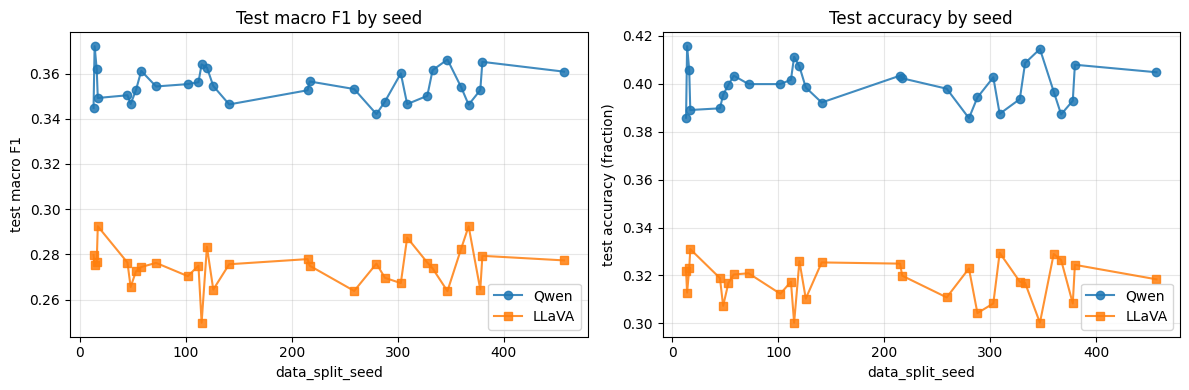

Saved: /home/ding-zhang/Dongmei/DATA255/Project/experiments/textonly_qwen_stratified_splits_robustness/metrics/qwen_vs_llava_stratified_paired_per_seed.csv


In [5]:
import glob
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

if "PROJECT_ROOT" not in dir():
    raise RuntimeError("Run the setup cell first (PROJECT_ROOT).")


def _acc_to_fraction(a: float) -> float:
    a = float(a)
    return a / 100.0 if a > 1.0 else a


def _load_qwen_json(path: str):
    with open(path) as f:
        d = json.load(f)
    seed = int(d.get("data_split_seed", d.get("configuration", {}).get("data_split_seed")))
    tm = d["test_metrics"]
    return (
        seed,
        float(tm["test_macro_f1"]),
        _acc_to_fraction(tm["test_accuracy"]),
        float(d.get("validation_metrics", {}).get("best_val_macro_f1", np.nan)),
    )


def _load_llava_json(path: str):
    with open(path) as f:
        d = json.load(f)
    seed = int(d.get("seed_value", d.get("configuration", {}).get("data_split_seed")))
    tm = d["test_metrics"]
    return (
        seed,
        float(tm["test_macro_f1"]),
        _acc_to_fraction(tm["test_accuracy"]),
        float(d.get("validation_metrics", {}).get("best_val_macro_f1", np.nan)),
    )


qdir = os.path.join(PROJECT_ROOT, "experiments", "textonly_qwen_stratified_splits_robustness", "metrics", "experiments")
ldir = os.path.join(PROJECT_ROOT, "experiments", "textonly_llava_stratified_robustness", "metrics", "experiments")

q_paths = sorted(glob.glob(os.path.join(qdir, "seed_*_results.json")))
l_paths = sorted(glob.glob(os.path.join(ldir, "seed_*_results.json")))
if not q_paths:
    raise FileNotFoundError(f"No Qwen result JSONs under {qdir}")
if not l_paths:
    raise FileNotFoundError(f"No LLaVA result JSONs under {ldir}")

df_q = pd.DataFrame(
    [_load_qwen_json(p) for p in q_paths],
    columns=["seed", "qwen_test_macro_f1", "qwen_test_acc_frac", "qwen_best_val_macro_f1"],
)
df_l = pd.DataFrame(
    [_load_llava_json(p) for p in l_paths],
    columns=["seed", "llava_test_macro_f1", "llava_test_acc_frac", "llava_best_val_macro_f1"],
)

df_per_seed = df_q.merge(df_l, on="seed", how="inner").sort_values("seed").reset_index(drop=True)
df_per_seed["delta_test_macro_f1"] = df_per_seed["qwen_test_macro_f1"] - df_per_seed["llava_test_macro_f1"]
df_per_seed["delta_test_acc_frac"] = df_per_seed["qwen_test_acc_frac"] - df_per_seed["llava_test_acc_frac"]
df_per_seed["delta_best_val_macro_f1"] = (
    df_per_seed["qwen_best_val_macro_f1"] - df_per_seed["llava_best_val_macro_f1"]
)

df_aggregate = pd.DataFrame(
    {
        "metric": ["test_macro_f1", "test_acc_frac", "best_val_macro_f1"],
        "qwen_mean": [
            df_per_seed["qwen_test_macro_f1"].mean(),
            df_per_seed["qwen_test_acc_frac"].mean(),
            df_per_seed["qwen_best_val_macro_f1"].mean(),
        ],
        "qwen_std": [
            df_per_seed["qwen_test_macro_f1"].std(ddof=1),
            df_per_seed["qwen_test_acc_frac"].std(ddof=1),
            df_per_seed["qwen_best_val_macro_f1"].std(ddof=1),
        ],
        "llava_mean": [
            df_per_seed["llava_test_macro_f1"].mean(),
            df_per_seed["llava_test_acc_frac"].mean(),
            df_per_seed["llava_best_val_macro_f1"].mean(),
        ],
        "llava_std": [
            df_per_seed["llava_test_macro_f1"].std(ddof=1),
            df_per_seed["llava_test_acc_frac"].std(ddof=1),
            df_per_seed["llava_best_val_macro_f1"].std(ddof=1),
        ],
        "mean_delta_qwen_minus_llava": [
            df_per_seed["delta_test_macro_f1"].mean(),
            df_per_seed["delta_test_acc_frac"].mean(),
            df_per_seed["delta_best_val_macro_f1"].mean(),
        ],
    }
)

# Alias for the paired-test cell
df = df_per_seed

print("Paths:", qdir, "|", ldir)
print("File counts:", len(q_paths), "Qwen,", len(l_paths), "LLaVA | matched rows:", len(df_per_seed))

print("\n### Per-seed (matched on seed)")
display(df_per_seed)

print("\n### Aggregate (matched seeds)")
display(df_aggregate)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = df_per_seed["seed"].values
axes[0].plot(x, df_per_seed["qwen_test_macro_f1"], "o-", label="Qwen", alpha=0.85)
axes[0].plot(x, df_per_seed["llava_test_macro_f1"], "s-", label="LLaVA", alpha=0.85)
axes[0].set_xlabel("data_split_seed")
axes[0].set_ylabel("test macro F1")
axes[0].legend()
axes[0].set_title("Test macro F1 by seed")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, df_per_seed["qwen_test_acc_frac"], "o-", label="Qwen", alpha=0.85)
axes[1].plot(x, df_per_seed["llava_test_acc_frac"], "s-", label="LLaVA", alpha=0.85)
axes[1].set_xlabel("data_split_seed")
axes[1].set_ylabel("test accuracy (fraction)")
axes[1].legend()
axes[1].set_title("Test accuracy by seed")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

out_csv = os.path.join(
    PROJECT_ROOT,
    "experiments",
    "textonly_qwen_stratified_splits_robustness",
    "metrics",
    "qwen_vs_llava_stratified_paired_per_seed.csv",
)
df_per_seed.to_csv(out_csv, index=False)
print("Saved:", out_csv)

## Paired tests: Qwen > LLaVA?

Uses the **`df`** table from the previous code cell (**same seeds, paired**).

For each metric, reports:

- **Paired *t*-test** (`scipy.stats.ttest_rel`), **one-sided** alternative **Qwen > LLaVA** (equivalent to testing mean of paired differences **> 0**).
- **Wilcoxon signed-rank** on paired differences (same one-sided direction).
- **95% CI** for the mean paired difference (Qwen − LLaVA), **Cohen’s \(d_z\)** (mean diff / SD of diffs), and **wins / ties / losses** counts.

**Two primary metrics here:** test macro F1 and test accuracy (fraction). With **α = 0.05** on each test, optionally apply **Bonferroni** and compare each *p*-value to **0.025** if you want a single family-wise claim across both metrics.

Output is a single **`df_paired_tests`** DataFrame (one row per metric).

In [7]:
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

if "df" not in dir():
    raise RuntimeError("Run the previous cell first (it defines `df`).")

ALPHA = 0.05
N_BOOT = 10_000
RNG = np.random.default_rng(42)


def bootstrap_paired_mean_diff(d: np.ndarray, n_boot: int = N_BOOT, rng: np.random.Generator = RNG):
    """Resample pair indices with replacement; mean of d on each replicate."""
    d = np.asarray(d, dtype=float)
    n = len(d)
    if n < 2:
        raise ValueError("Need at least 2 pairs for bootstrap.")
    # (n_boot, n) indices — vectorized
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = d[idx].mean(axis=1)
    ci_lo, ci_hi = np.quantile(boot_means, [0.025, 0.975])
    # One-sided p (Qwen > LLaVA): small if mass of bootstrap means is above 0
    p_one_sided = (1.0 + np.sum(boot_means <= 0.0)) / (n_boot + 1.0)
    return float(ci_lo), float(ci_hi), float(p_one_sided), boot_means


def paired_test_rows(metric_label: str, qwen: np.ndarray, llava: np.ndarray, alpha: float = ALPHA):
    qwen = np.asarray(qwen, dtype=float)
    llava = np.asarray(llava, dtype=float)
    d = qwen - llava
    n = len(d)
    mean_d = float(np.mean(d))
    std_d = float(np.std(d, ddof=1)) if n > 1 else 0.0
    cohen_dz = mean_d / std_d if std_d > 1e-12 else np.nan

    t_res = stats.ttest_rel(qwen, llava, alternative="greater")
    try:
        w_res = stats.wilcoxon(d, alternative="greater", zero_method="wilcox", method="approx")
    except TypeError:
        w_res = stats.wilcoxon(d, alternative="greater", zero_method="wilcox")

    if n > 1:
        se = stats.sem(d)
        h = se * stats.t.ppf((1 + 0.95) / 2.0, n - 1)
        ci_lo, ci_hi = mean_d - h, mean_d + h
    else:
        ci_lo = ci_hi = mean_d

    wins = int(np.sum(d > 0))
    ties = int(np.sum(d == 0))
    losses = int(np.sum(d < 0))

    boot_ci_lo, boot_ci_hi, boot_p_one, _ = bootstrap_paired_mean_diff(d, n_boot=N_BOOT, rng=RNG)
    boot_rejects = boot_ci_lo > 0.0  # "CI entirely > 0" (same spirit as your fusion table)

    return {
        "metric": metric_label,
        "n_pairs": n,
        "mean_diff_qwen_minus_llava": mean_d,
        "std_diff": std_d,
        "cohen_dz_paired": cohen_dz,
        "ci95_mean_diff_lo": ci_lo,
        "ci95_mean_diff_hi": ci_hi,
        "t_statistic": float(t_res.statistic),
        "t_p_one_sided_qwen_gt_llava": float(t_res.pvalue),
        "reject_t_H0_at_alpha": bool(t_res.pvalue < alpha),
        "wilcoxon_statistic": float(w_res.statistic) if w_res.statistic is not None else np.nan,
        "wilcoxon_p_one_sided": float(w_res.pvalue),
        "reject_wilcoxon_H0_at_alpha": bool(w_res.pvalue < alpha),
        "wins_qwen": wins,
        "ties": ties,
        "losses_qwen": losses,
        "boot_ci95_mean_diff_lo": boot_ci_lo,
        "boot_ci95_mean_diff_hi": boot_ci_hi,
        "boot_ci_entirely_gt_0": bool(boot_rejects),
        "boot_p_one_sided_qwen_gt_llava": boot_p_one,
        "reject_boot_H0_at_alpha": bool(boot_p_one < alpha),
    }


df_paired_tests = pd.DataFrame(
    [
        paired_test_rows("test_macro_f1", df["qwen_test_macro_f1"].values, df["llava_test_macro_f1"].values),
        paired_test_rows("test_accuracy_frac", df["qwen_test_acc_frac"].values, df["llava_test_acc_frac"].values),
    ]
)

print(
    f"Paired tests: one-sided Qwen > LLaVA | alpha = {ALPHA} | "
    f"bootstrap mean-delta: {N_BOOT:,} resamples, seed={RNG.bit_generator._seed_seq.entropy if hasattr(RNG, 'bit_generator') else 'default_rng(42)'}"
)
print("Parametric CI = classical t interval on mean paired difference; Boot CI = percentile interval on bootstrap mean(d).")
display(df_paired_tests)

Paired tests: one-sided Qwen > LLaVA | alpha = 0.05 | bootstrap mean-delta: 10,000 resamples, seed=42
Parametric CI = classical t interval on mean paired difference; Boot CI = percentile interval on bootstrap mean(d).


,metric,n_pairs,mean_diff_qwen_minus_llava,std_diff,cohen_dz_paired,ci95_mean_diff_lo,ci95_mean_diff_hi,t_statistic,t_p_one_sided_qwen_gt_llava,reject_t_H0_at_alpha,...,wilcoxon_p_one_sided,reject_wilcoxon_H0_at_alpha,wins_qwen,ties,losses_qwen,boot_ci95_mean_diff_lo,boot_ci95_mean_diff_hi,boot_ci_entirely_gt_0,boot_p_one_sided_qwen_gt_llava,reject_boot_H0_at_alpha
0,test_macro_f1,30,0.080458,0.013059,6.161130,0.075581,0.085334,33.745898,3.972628e-25,True,...,8.671988e-07,True,30,0,0,0.075758,0.085168,True,0.0001,True
1,test_accuracy_frac,30,0.081653,0.014033,5.818473,0.076413,0.086893,31.869089,2.001906e-24,True,...,8.671988e-07,True,30,0,0,0.076810,0.086563,True,0.0001,True
